#                                         Emotion Detection by YOLO model

In [ ]:
# Check GPU Status in Google Colob or Local Machine
!nvidia-smi  # For GPU


!nvidia-smi  # For GPU


# **Cuda**

In [ ]:
# Check if GPU is available with pytorch
import torch
print(torch.cuda.is_available()) # True if GPU is avilable

In [1]:


# Install known-compatible versions
!pip install \
numpy==1.26.4 \
scipy==1.11.4 \
seaborn==0.13.2 \
matplotlib==3.8.4 \
pandas==2.1.4 \
opencv-python==4.9.0.80 \
roboflow \
ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 58.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 111.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 127.0 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.2/62.2 MB 32.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 39.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 88.6 MB/s eta 0:00:00:00:0

# **Import the required libraries and initialize the model**

In [2]:
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from roboflow import Roboflow
from ultralytics import YOLO
from collections import Counter
from glob import glob
import yaml
print('all libraries are imported')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
all libraries are imported


# Data Load

In [3]:


from roboflow import Roboflow
rf = Roboflow(api_key="eAi1V5KJP8PwAbKVhx4O")
project = rf.workspace("daya-r4ucb").project("emotion-gyup3-l67hn")
version = project.version(1)
dataset = version.download("yolov8")
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to emotion-1 in yolov8:: 100%|██████████| 8528/8528 [00:00<00:00, 9288.15it/s] 


In [4]:
# Update this to the actual downloaded folder name (it will be printed after download)
data_path = "/kaggle/working/emotion-1"  # e.g., "emotion-detection-5"
train_path = os.path.join(data_path, "train")
val_path = os.path.join(data_path, "valid")
test_path = os.path.join(data_path, "test")

# Load class names
with open(os.path.join(data_path, "data.yaml"), 'r') as f:
    data_yaml = yaml.safe_load(f)

class_names = data_yaml['names']
num_classes = len(class_names)
print(f"Classes ({num_classes}): {class_names}")

Classes (7): ['angry', 'happy', 'relax', 'rock', 'romantic', 'sad', 'surprise']


# Sample data display

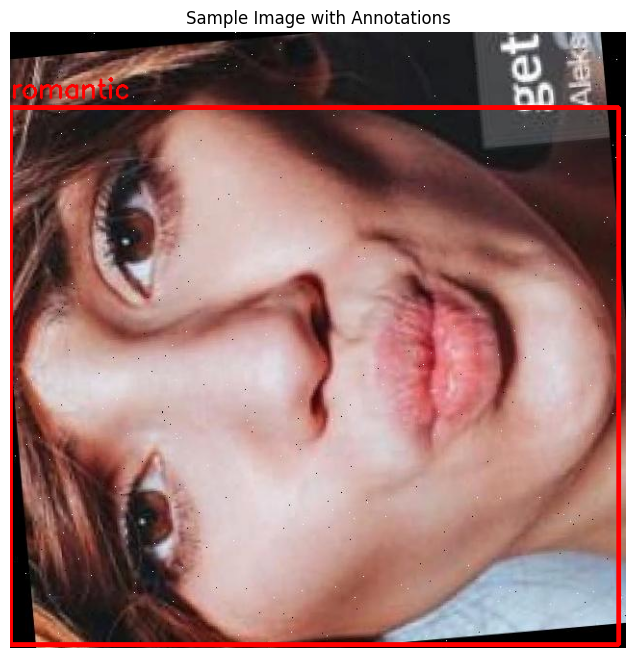

In [5]:
# Step 4: Sample data display
def display_sample_image(img_path, label_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            labels = f.readlines()
        
        for label in labels:
            parts = label.strip().split()
            if len(parts) != 5:
                continue
            cls, x, y, bw, bh = map(float, parts)
            cls = int(cls)
            x1 = int((x - bw/2) * w)
            y1 = int((y - bh/2) * h)
            x2 = int((x + bw/2) * w)
            y2 = int((y + bh/2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
            cv2.putText(img, class_names[cls], (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Sample Image with Annotations")
    plt.show()

# Get a sample image
sample_imgs = glob(os.path.join(train_path, "images", "*.*"))  # supports jpg, png, etc.
if sample_imgs:
    sample_img = sample_imgs[16]
    sample_label = os.path.splitext(sample_img.replace("images", "labels"))[0] + ".txt"
    display_sample_image(sample_img, sample_label)
else:
    print("No images found in train folder.")

# EDA

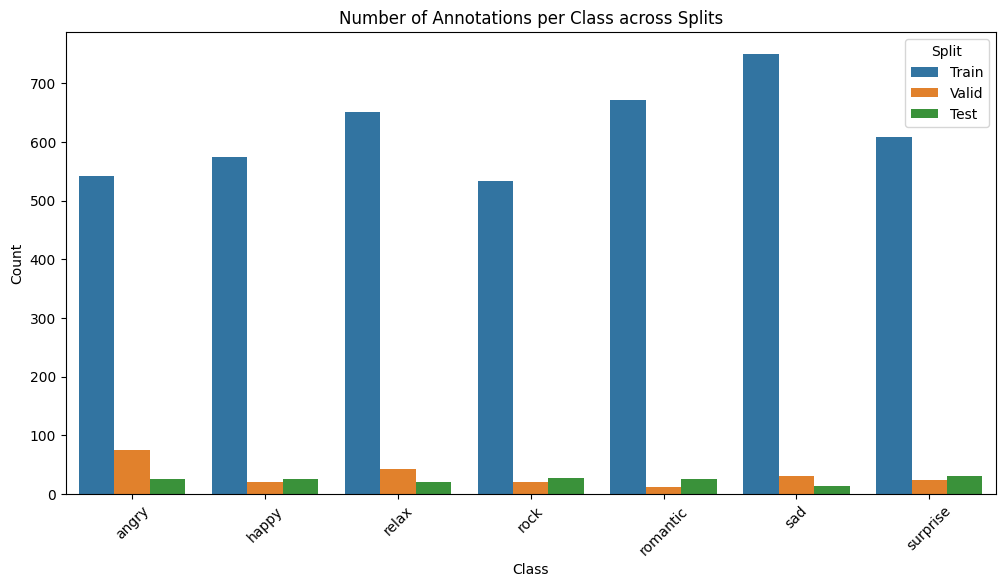

Train images: 3909
Valid images: 192
Test images: 157
Average bounding boxes per train image: 1.11


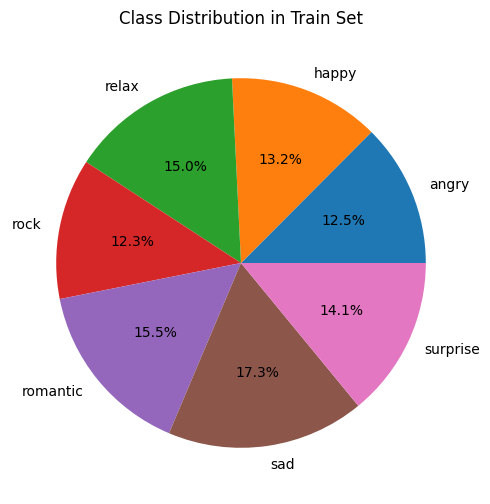

In [6]:
# Step 5: EDA - Number of images per class
# Function to count annotations per class
def count_per_class(label_dir):
    class_counts = Counter()
    for label_file in glob(os.path.join(label_dir, "*.txt")):
        with open(label_file, 'r') as f:
            labels = f.readlines()
            for label in labels:
                cls = int(label.strip().split()[0])
                class_counts[cls] += 1
    return class_counts

train_counts = count_per_class(os.path.join(train_path, "labels"))
val_counts = count_per_class(os.path.join(val_path, "labels"))
test_counts = count_per_class(os.path.join(test_path, "labels"))

# Create DataFrame for plotting
df = pd.DataFrame({
    "Class": class_names * 3,
    "Count": list(train_counts.values()) + list(val_counts.values()) + list(test_counts.values()),
    "Split": ["Train"] * num_classes + ["Valid"] * num_classes + ["Test"] * num_classes
})

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="Class", y="Count", hue="Split")
plt.title("Number of Annotations per Class across Splits")
plt.xticks(rotation=45)
plt.show()

# More EDA: Number of images in each split
num_train_imgs = len(glob(os.path.join(train_path, "images", "*.jpg")))
num_val_imgs = len(glob(os.path.join(val_path, "images", "*.jpg")))
num_test_imgs = len(glob(os.path.join(test_path, "images", "*.jpg")))

print(f"Train images: {num_train_imgs}")
print(f"Valid images: {num_val_imgs}")
print(f"Test images: {num_test_imgs}")

# Average bounding boxes per image (for train)
total_bboxes_train = sum(train_counts.values())
avg_bboxes_train = total_bboxes_train / num_train_imgs if num_train_imgs > 0 else 0
print(f"Average bounding boxes per train image: {avg_bboxes_train:.2f}")

# Distribution of classes
plt.figure(figsize=(8, 6))
plt.pie(train_counts.values(), labels=class_names, autopct='%1.1f%%')
plt.title("Class Distribution in Train Set")
plt.show()

# **Train the model**

In [7]:
# Load YOLOv8n model
model = YOLO("yolov8n.pt")  # Pre-trained YOLOv8 nano model
# Train the YOLOv8 model
results = model.train(
    data = "/kaggle/working/emotion-1/data.yaml",  # Path to dataset YAML file
    epochs = 30,           # Number of epochs
    imgsz = 640,           # Image size
    batch = 6,             # Batch size
    lr0 = 0.001,            # Initial learning rate
    workers = 2,           # Number of data loader workers
    optimizer = "AdamW",     # Optimizer (SGD or Adam)
    patience = 5,         # stop if no improvement for 5 epochs
    device = 0        # Device to use (0 for GPU, 'cpu' for CPU)
)

Ultralytics 8.3.237 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/emotion-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=5, perspective=0.0, plo

invalid value encountered in less
invalid value encountered in less


                   all        192        224      0.929      0.882      0.951      0.698
                 angry         12         12      0.873       0.75       0.89      0.691
                 happy         30         30      0.948        0.9       0.97       0.74
                 relax         43         75      0.964      0.711      0.873      0.397
                  rock         20         20      0.978       0.95      0.993       0.69
              romantic         24         24      0.929          1      0.995      0.773
                   sad         42         42      0.838      0.862      0.938      0.614
              surprise         21         21      0.972          1      0.995      0.981
Speed: 0.2ms preprocess, 2.7ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to /kaggle/working/runs/detect/train


# **Validate the model**

In [8]:
# Validation on the validation set (after training)
print("\nValidating the model on validation set...")
val_results = model.val()  # By default uses the 'val' split from your data.yaml

# Extract and print the key detection metrics
print(f"Validation mAP@0.5:      {val_results.box.map50:.4f}")
print(f"Validation mAP@0.5:0.95: {val_results.box.map:.4f}")


# Optional: Print per-class mAP@0.5
print("\nPer-class mAP@0.5:")
for i, class_name in enumerate(val_results.names.values()):
    class_map50 = val_results.box.maps[i] if hasattr(val_results.box, 'maps') else "N/A"
    print(f"  {class_name:12s}: {class_map50:.4f}")


Validating the model on validation set...
Ultralytics 8.3.237 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 943.6±190.2 MB/s, size: 31.9 KB)
val: Scanning /kaggle/working/emotion-1/valid/labels.cache... 192 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 192/192 425.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 4.4it/s 2.7s0.2s


invalid value encountered in less
invalid value encountered in less


                   all        192        224      0.932      0.886      0.953      0.698
                 angry         12         12      0.874       0.75       0.89      0.691
                 happy         30         30      0.948        0.9       0.97      0.739
                 relax         43         75      0.964      0.711      0.873      0.399
                  rock         20         20      0.978       0.95      0.993       0.69
              romantic         24         24      0.929          1      0.995      0.773
                   sad         42         42      0.861      0.887      0.956      0.616
              surprise         21         21      0.972          1      0.995      0.981
Speed: 3.0ms preprocess, 2.5ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
Validation mAP@0.5:      0.9531
Validation mAP@0.5:0.95: 0.6985

Per-class mAP@0.5:
  angry       : 0.6913
  happy       : 0.7393
  relax       : 0.3988
  ro

In [9]:
print("\nValidating the model on TEST set...")
test_results = model.val(split='test')  # Explicitly use the test split

print(f"Test mAP@0.5:      {test_results.box.map50:.4f}")
print(f"Test mAP@0.5:0.95: {test_results.box.map:.4f}")


Validating the model on TEST set...
Ultralytics 8.3.237 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 558.1±19.0 MB/s, size: 30.9 KB)
val: Scanning /kaggle/working/emotion-1/test/labels... 157 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 157/157 1.4Kit/s 0.1s<0.0s
val: New cache created: /kaggle/working/emotion-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 4.1it/s 2.4s.3ss


invalid value encountered in less
invalid value encountered in less


                   all        157        168      0.943      0.884      0.954      0.692
                 angry         14         14      0.924      0.929      0.952      0.732
                 happy         25         25      0.911       0.84      0.953      0.724
                 relax         19         30          1      0.863      0.963      0.467
                  rock         27         27      0.975      0.963      0.992      0.666
              romantic         25         25      0.958      0.902      0.937      0.698
                   sad         26         26      0.859      0.692      0.884      0.604
              surprise         21         21      0.976          1      0.995      0.951
Speed: 3.4ms preprocess, 2.8ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /kaggle/working/runs/detect/val2
Test mAP@0.5:      0.9537
Test mAP@0.5:0.95: 0.6917


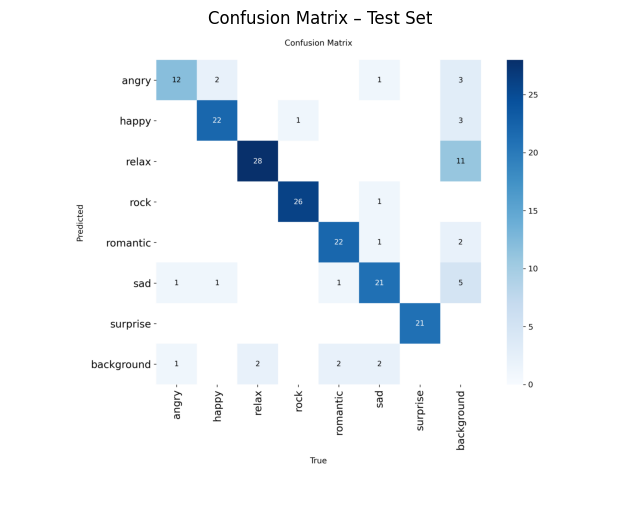

In [17]:
import matplotlib.pyplot as plt
import cv2

cm_path = "runs/detect/val2/confusion_matrix.png"

img = cv2.imread(cm_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Confusion Matrix – Test Set")
plt.show()


# **Underfitting Vs Overfitting Plot**

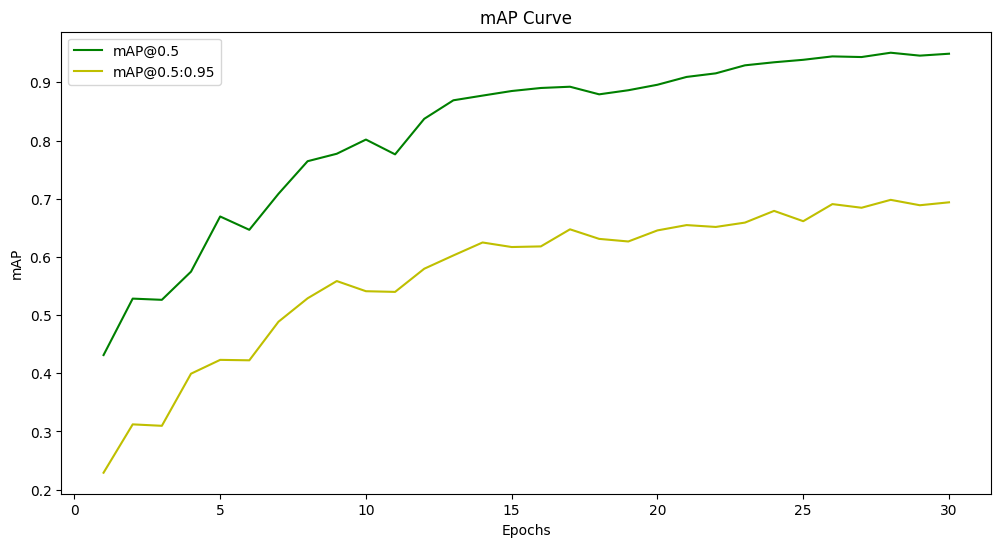

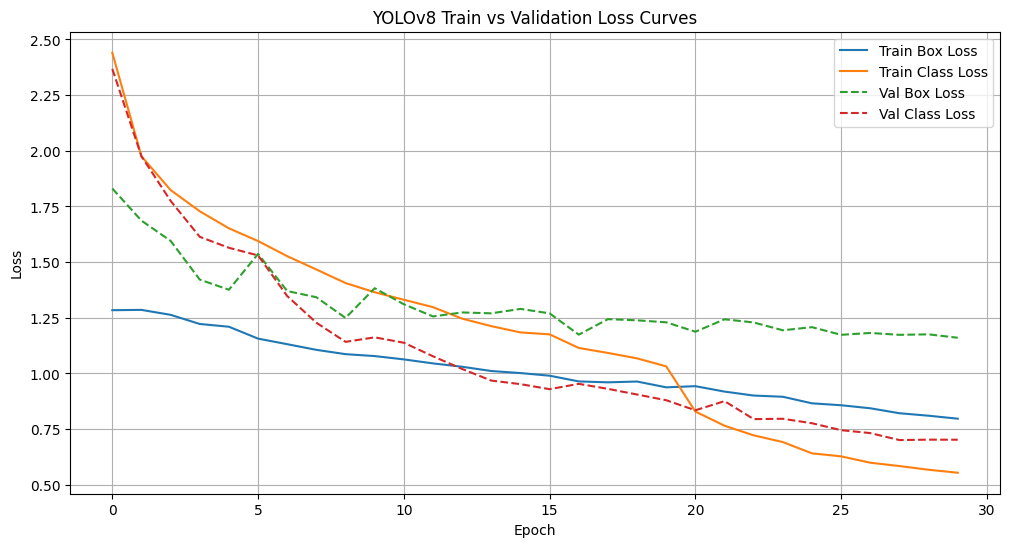

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load training results
csv_path = "/kaggle/working/runs/detect/train/results.csv"  # Update path if needed
df = pd.read_csv(csv_path)


# Plot mAP curves
plt.figure(figsize = (12, 6)) # Set the figure size
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label = "mAP@0.5", color = "g") # plot mAP@0.5 curve
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label = "mAP@0.5:0.95", color = "y") # plot mAP@0.5:0.95 curve
plt.xlabel("Epochs") # Set the x-axis label
plt.ylabel("mAP")    # Set the y-axis label
plt.title("mAP Curve") # Set the title of the plot
plt.legend() # Show the legend
plt.show()   # Display the plot



results_df = pd.read_csv(csv_path)
plt.figure(figsize=(12, 6))

# Training losses
plt.plot(results_df["train/box_loss"], label="Train Box Loss")
plt.plot(results_df["train/cls_loss"], label="Train Class Loss")


# Validation losses
plt.plot(results_df["val/box_loss"], linestyle="--", label="Val Box Loss")
plt.plot(results_df["val/cls_loss"], linestyle="--", label="Val Class Loss")


plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("YOLOv8 Train vs Validation Loss Curves")
plt.legend()
plt.grid(True)
plt.show()



# **Test the model on new images**


image 1/1 /kaggle/working/emotion-1/test/images/38181_png_jpg.rf.7ae81f619f9450b275cdd9ab9c105038.jpg: 640x640 1 happy, 7.3ms
Speed: 1.5ms preprocess, 7.3ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


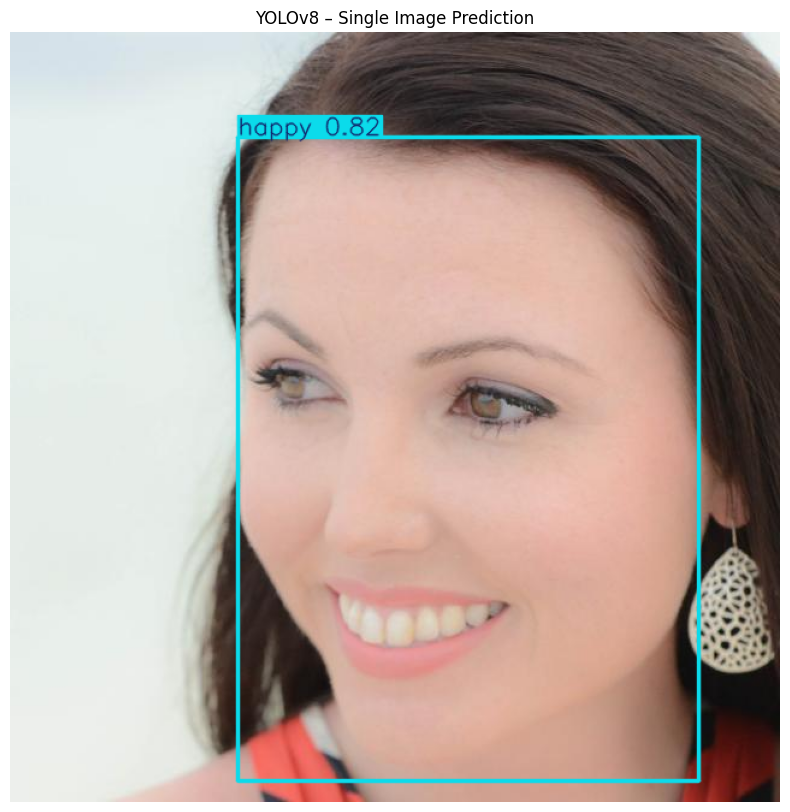

Detections:
- happy | confidence: 0.82


In [11]:
# ===============================
# YOLOv8 SINGLE IMAGE INFERENCE
# ===============================

from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import os

# -------------------------------
# 1. Paths (EDIT THESE)
# -------------------------------
model_path = "/kaggle/working/runs/detect/train/weights/best.pt"
image_path = "/kaggle/working/emotion-1/test/images/38181_png_jpg.rf.7ae81f619f9450b275cdd9ab9c105038.jpg"

# Safety checks
assert os.path.exists(model_path), "Model file not found"
assert os.path.exists(image_path), "Image file not found"

# -------------------------------
# 2. Load trained model
# -------------------------------
model = YOLO(model_path)

# -------------------------------
# 3. Run prediction on ONE image
# -------------------------------
results = model.predict(
    source=image_path,
    imgsz=640,
    conf=0.50,
    device=0
)

# -------------------------------
# 4. Display prediction (FIXED COLORS)
# -------------------------------
annotated_img = results[0].plot()

# Convert BGR → RGB for correct colors
annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(annotated_img)
plt.axis("off")
plt.title("YOLOv8 – Single Image Prediction")
plt.show()

# -------------------------------
# 5. Print detected objects
# -------------------------------
print("Detections:")
for box in results[0].boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    class_name = model.names[cls_id]
    print(f"- {class_name} | confidence: {conf:.2f}")


# **mAP Comparion**

Test mAP@0.5:      0.9537
Test mAP@0.5:0.95: 0.6917


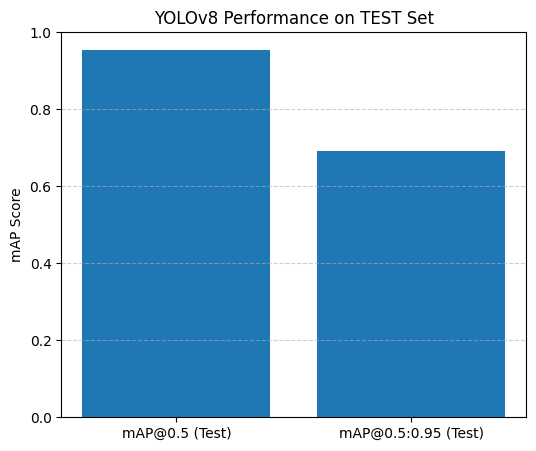

In [12]:
import matplotlib.pyplot as plt

# Extract mAP values
map_50 = test_results.box.map50
map_5095 = test_results.box.map

# Print values
print(f"Test mAP@0.5:      {map_50:.4f}")
print(f"Test mAP@0.5:0.95: {map_5095:.4f}")

# -------------------------------
# Bar plot for Test mAP
# -------------------------------
plt.figure(figsize=(6, 5))
plt.bar(
    ["mAP@0.5 (Test)", "mAP@0.5:0.95 (Test)"],
    [map_50, map_5095]
)

plt.ylim(0, 1)
plt.ylabel("mAP Score")
plt.title("YOLOv8 Performance on TEST Set")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


# Model structure

In [13]:
print(model.model)

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1))
        (act): SiLU(inplace=True)
      )
      (m): ModuleList(
        (0): Bottleneck(
          (cv1): Conv(
            (conv): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (act): SiLU(inplace=True)
          )
          (cv2): Conv(
            (conv): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (act): SiLU(inplace=True)
          )
        )
      )
    )
    (3): Conv(
      (conv): Conv2d(32

In [14]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 103.2 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=1f3acec50f2272949a311c56ea5e1366a15692eaed081672b6a8718362ddb230
  Stored in directory: /root/.cache/pip/wheels/bc/52/78/893c3b94279ef238f43a9e89608af648de401b96415bebbd1f
Successfully built grad-cam



image 1/1 /kaggle/working/emotion-1/test/images/38181_png_jpg.rf.7ae81f619f9450b275cdd9ab9c105038.jpg: 640x640 1 happy, 6.2ms
Speed: 1.6ms preprocess, 6.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


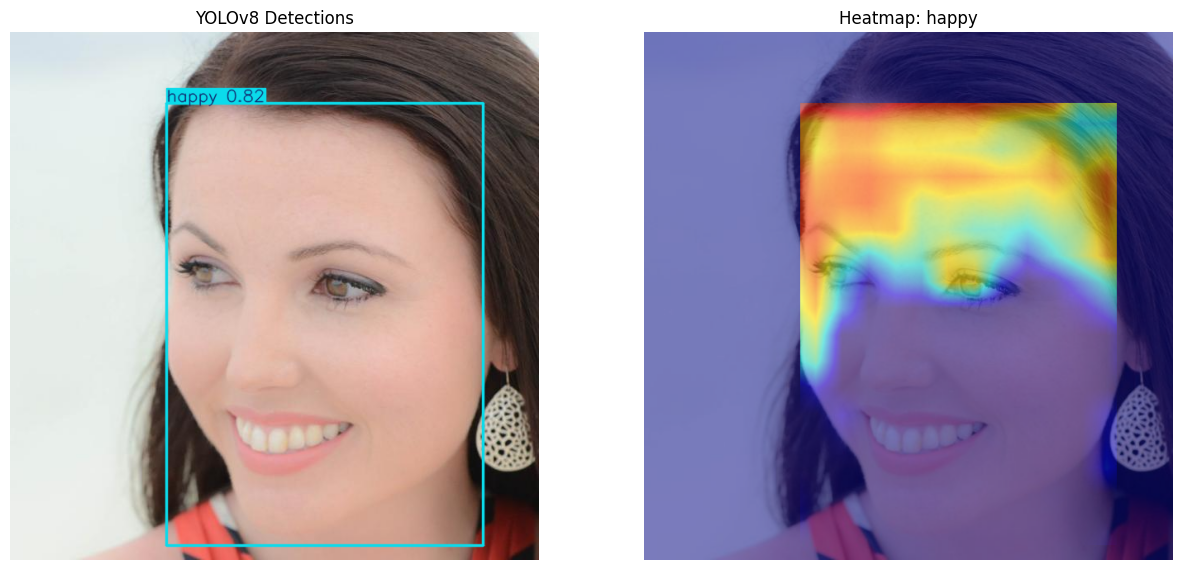

Detections:
- happy | confidence: 0.82


In [23]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import os
import torch
import numpy as np
from pytorch_grad_cam import EigenCAM  # Or GradCAM if you prefer gradient-based
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# -------------------------------
# Your existing paths and model load
# -------------------------------
model_path = "/kaggle/working/runs/detect/train/weights/best.pt"
image_path = "/kaggle/working/emotion-1/test/images/38181_png_jpg.rf.7ae81f619f9450b275cdd9ab9c105038.jpg"

assert os.path.exists(model_path), "Model file not found"
assert os.path.exists(image_path), "Image file not found"

model = YOLO(model_path)

# Load the underlying PyTorch model (for grad-cam access)
torch_model = model.model  # This is the nn.Module

# Run standard prediction to get detections
results = model.predict(
    source=image_path,
    imgsz=640,
    conf=0.50,
    device=0
)

# -------------------------------
# Prepare image for grad-cam
# -------------------------------
orig_img = cv2.imread(image_path)
orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
input_img = orig_img.copy()

# Resize and normalize like YOLO does internally (approximate)
input_tensor = cv2.resize(input_img, (640, 640))
input_tensor = input_tensor / 255.0
input_tensor = input_tensor.astype(np.float32)
input_tensor = torch.from_numpy(input_tensor).permute(2, 0, 1).unsqueeze(0).to('cuda' if torch.cuda.is_available() else 'cpu')

# -------------------------------
# Choose target layers (important!)
# -------------------------------
# For YOLOv8 detection heads (P3, P4, P5 outputs), good layers are the last convs before detect:
# Common choices: model[-1] is Detect layer, so try layers like model.model[-1].cv3 or earlier backbone.
# Experiment with these (print model.model to see layers):
target_layers = [torch_model.model[-2]]  # Often a good late feature layer (adjust if needed, e.g., model.model[22] for backbone end)

# Create CAM object (use EigenCAM for detection; switch to GradCAM for true Grad-CAM)
cam = EigenCAM(model=torch_model, target_layers=target_layers)

# -------------------------------
# Get detections for targets
# -------------------------------
detections = results[0].boxes  # List of detected boxes
class_ids = detections.cls.cpu().numpy().astype(int)

# For each detection, generate a class-specific heatmap
heatmap_overlays = []
for cls_id in np.unique(class_ids):
    # Target this specific class
    targets = [ClassifierOutputTarget(cls_id)]
    
    # Compute CAM
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]  # Take first batch
    
    # Optional: renormalize inside bounding boxes for this class only
    class_boxes = detections.xyxy[detections.cls == cls_id].cpu().numpy()
    if len(class_boxes) > 0:
        mask = np.zeros(grayscale_cam.shape, dtype=np.float32)
        for box in class_boxes:
            x1, y1, x2, y2 = map(int, box)
            # Scale box to 640x640
            x1 = int(x1 / orig_img.shape[1] * 640)
            y1 = int(y1 / orig_img.shape[0] * 640)
            x2 = int(x2 / orig_img.shape[1] * 640)
            y2 = int(y2 / orig_img.shape[0] * 640)
            mask[y1:y2, x1:x2] = grayscale_cam[y1:y2, x1:x2]
        # Normalize inside boxes
        if mask.max() > 0:
            grayscale_cam = mask / mask.max()
    
    # Overlay heatmap on resized image then resize back
    visualization = show_cam_on_image(input_img / 255.0, grayscale_cam, use_rgb=True)
    visualization = cv2.resize(visualization, (orig_img.shape[1], orig_img.shape[0]))
    heatmap_overlays.append(visualization)

# -------------------------------
# Display results
# -------------------------------
# Original annotated image (your existing code)
annotated_img = results[0].plot()
annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 10))
plt.subplot(1, len(heatmap_overlays) + 1, 1)
plt.imshow(annotated_img)
plt.title("YOLOv8 Detections")
plt.axis("off")

for i, overlay in enumerate(heatmap_overlays):
    class_name = model.names[np.unique(class_ids)[i]]
    plt.subplot(1, len(heatmap_overlays) + 1, i + 2)
    plt.imshow(overlay)
    plt.title(f"Heatmap: {class_name}")
    plt.axis("off")

plt.show()

# Print detections (your existing)
print("Detections:")
for box in results[0].boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    class_name = model.names[cls_id]
    print(f"- {class_name} | confidence: {conf:.2f}")

In [24]:
!zip -r final.zip /kaggle/working


  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/runs/ (stored 0%)
  adding: kaggle/working/runs/detect/ (stored 0%)
  adding: kaggle/working/runs/detect/val2/ (stored 0%)
  adding: kaggle/working/runs/detect/val2/BoxPR_curve.png (deflated 18%)
  adding: kaggle/working/runs/detect/val2/val_batch2_pred.jpg (deflated 8%)
  adding: kaggle/working/runs/detect/val2/val_batch2_labels.jpg (deflated 8%)
  adding: kaggle/working/runs/detect/val2/val_batch0_pred.jpg (deflated 9%)
  adding: kaggle/working/runs/detect/val2/val_batch1_pred.jpg (deflated 10%)
  adding: kaggle/working/runs/detect/val2/val_batch0_labels.jpg (deflated 9%)
  adding: kaggle/working/runs/detect/val2/val_batch1_labels.jpg (deflated 10%)
  adding: kaggle/working/runs/detect/val2/confusion_matrix_normalized.png (deflated 20%)
  adding: kaggle/working/runs/detect/val2/BoxR_curve.png (deflated 8%)
  adding: kaggle/working/runs/detect/val2/BoxF1_curve.png (deflated 6%)
  adding: kaggle/working/runs/detect/val2/con